# unique_train.h5: Distribution Explorer & Training Balance Notes

**目标文件**: `/mnt/raid5/cliang/project_MS2predict/0.data/train_data/unique_train.h5`

本 notebook 对所有关键特征做分布可视化，并给出深度学习训练的数据平衡建议。

In [37]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import matplotlib.pyplot as plt
plt.style.use('default')  # 使用 Matplotlib 默认白色背景

matplotlib.rcParams.update({
    "font.size": 11,
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

H5_PATH = "/mnt/raid5/cliang/project_MS2predict/0.data/train_data/unique_train.h5"
f = h5py.File(H5_PATH, "r")

print("=== Datasets ===")
for k in sorted(f.keys()):
    ds = f[k]
    print(f"  {k}: shape={ds.shape}, dtype={ds.dtype}")

N = f["Score"].shape[0]
print(f"\nTotal rows: {N:,}")


=== Datasets ===
  Charge: shape=(3082919,), dtype=int64
  Fragmentation: shape=(3082919,), dtype=|S3
  Length: shape=(3082919,), dtype=int64
  MS2_Scan_Number: shape=(3082919,), dtype=int64
  Mass_analyzer: shape=(3082919,), dtype=|S4
  Modifications: shape=(3082919,), dtype=|S39
  Modified_sequence: shape=(3082919,), dtype=|S110
  RT: shape=(3082919,), dtype=float64
  Raw_file: shape=(3082919,), dtype=|S58
  Reverse: shape=(3082919,), dtype=|S3
  Score: shape=(3082919,), dtype=float64
  Sequence: shape=(3082919,), dtype=|S40
  annotate: shape=(3082919,), dtype=|S174
  collision_energy: shape=(3082919,), dtype=float64
  dataset: shape=(3082919,), dtype=|S20
  instrument: shape=(3082919,), dtype=|S21
  source_row_id: shape=(3082919,), dtype=uint32
  train_data: shape=(3082919, 39, 41), dtype=float64

Total rows: 3,082,919


In [38]:
# 一次性加载所有元数据列（约 2-3 GB），不加载 train_data
charge   = f["Charge"][:]
length   = f["Length"][:]
ce       = f["collision_energy"][:]
score    = f["Score"][:]
frag     = np.char.decode(f["Fragmentation"][:], "utf-8")
mods     = np.char.decode(f["Modifications"][:], "utf-8")
inst     = np.char.decode(f["instrument"][:], "utf-8")
dataset  = np.char.decode(f["dataset"][:], "utf-8")
reverse_col = np.char.decode(f["Reverse"][:], "utf-8")
sequence = np.char.decode(f["Sequence"][:], "utf-8")

print(f"Metadata loaded: {N:,} rows")

Metadata loaded: 3,082,919 rows


## 1. Charge Distribution

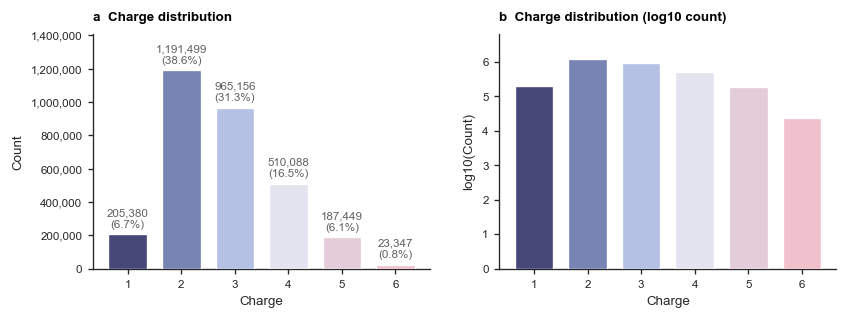


Imbalance: max/min = 51x
Charge 2+3 share: 70.0%


In [41]:
vals, cnts = np.unique(charge, return_counts=True)

# Nature / NMI pastel palette
PALETTE_NMI = {
    "baseline_dark": "#484878",
    "baseline_mid": "#7884B4",
    "baseline_soft": "#B4C0E4",
    "ours_tiny": "#E4E4F0",
    "ours_base": "#E4CCD8",
    "ours_large": "#F0C0CC",
    "neutral_dark": "#606060",
}
CHARGE_COLORS = [
    PALETTE_NMI["baseline_dark"],
    PALETTE_NMI["baseline_mid"],
    PALETTE_NMI["baseline_soft"],
    PALETTE_NMI["ours_tiny"],
    PALETTE_NMI["ours_base"],
    PALETTE_NMI["ours_large"],
    PALETTE_NMI["baseline_mid"],
]
colors = [CHARGE_COLORS[i % len(CHARGE_COLORS)] for i in range(len(vals))]

with plt.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "svg.fonttype": "none",
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#272727",
    "axes.labelcolor": "#272727",
    "xtick.color": "#272727",
    "ytick.color": "#272727",
    "legend.frameon": False,
    "axes.grid": False,
}):
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), facecolor="white")

    xlabels = vals.astype(str)
    bar_kwargs = {"width": 0.72, "edgecolor": "white", "linewidth": 0.8, "zorder": 3}

    # 柱状图
    axes[0].bar(xlabels, cnts, color=colors, **bar_kwargs)
    ymax0 = cnts.max() * 1.18
    axes[0].set_ylim(0, ymax0)
    for v, c in zip(vals, cnts):
        axes[0].text(
            str(v),
            c + ymax0 * 0.02,
            f"{c:,}\n({c/N*100:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=7,
            color=PALETTE_NMI["neutral_dark"],
        )
    axes[0].set_xlabel("Charge", fontsize=8)
    axes[0].set_ylabel("Count", fontsize=8)
    axes[0].set_title("a  Charge distribution", loc="left", fontsize=8, fontweight="bold", pad=8)
    axes[0].tick_params(axis="both", labelsize=7, length=3, width=0.8)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # log10(count) 线性 y 轴
    log_cnts = np.where(cnts > 0, np.log10(cnts), 0.0)
    axes[1].bar(xlabels, log_cnts, color=colors, **bar_kwargs)
    ymax1 = log_cnts.max() * 1.12 if log_cnts.max() > 0 else 1.0
    axes[1].set_ylim(0, ymax1)
    axes[1].set_xlabel("Charge", fontsize=8)
    axes[1].set_ylabel("log10(Count)", fontsize=8)
    axes[1].set_title("b  Charge distribution (log10 count)", loc="left", fontsize=8, fontweight="bold", pad=8)
    axes[1].tick_params(axis="both", labelsize=7, length=3, width=0.8)

    plt.tight_layout(w_pad=1.8)
    plt.show()

print(f"\nImbalance: max/min = {cnts.max()/cnts.min():.0f}x")
print(f"Charge 2+3 share: {(cnts[vals==2].sum() + cnts[vals==3].sum()) / N * 100:.1f}%")

## 2. Peptide Length (Length) Distribution

/tmp/ipykernel_1933858/3968053341.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


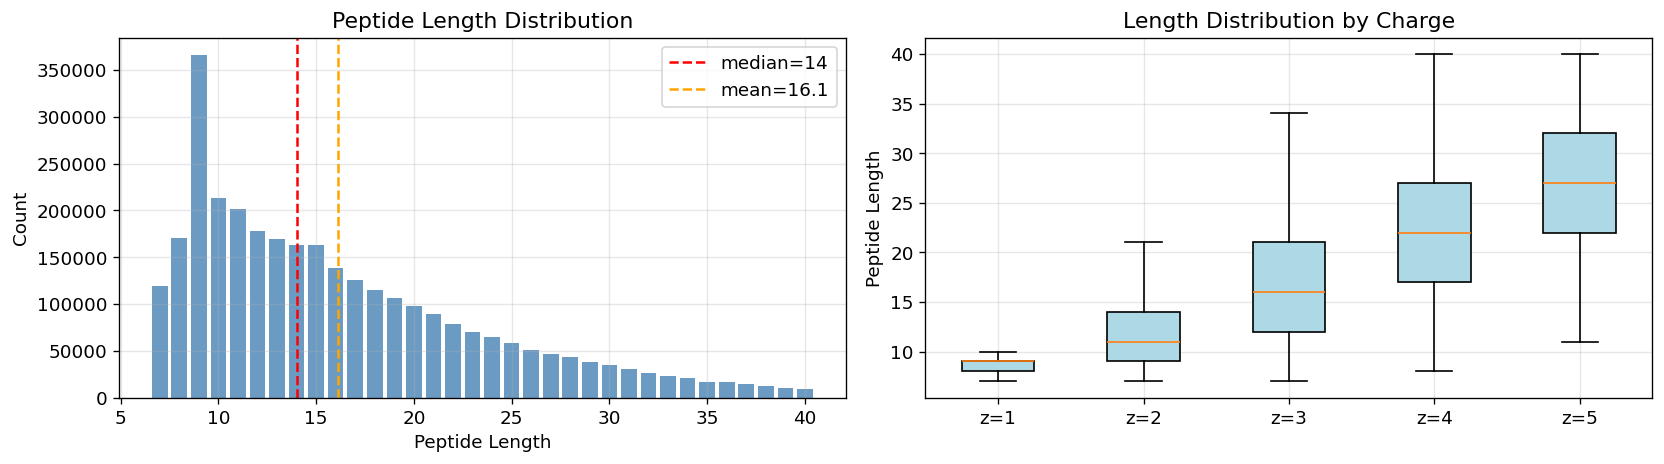

Length < 8:  118,784 (3.85%)
Length > 30: 180,250 (5.85%)
Length 8-25: 2,569,671 (83.4%)


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 直方图
len_vals, len_cnts = np.unique(length, return_counts=True)
axes[0].bar(len_vals, len_cnts, width=0.8, color="steelblue", alpha=0.8)
axes[0].axvline(np.median(length), color="red", ls="--", label=f"median={np.median(length):.0f}")
axes[0].axvline(np.mean(length), color="orange", ls="--", label=f"mean={np.mean(length):.1f}")
axes[0].set_xlabel("Peptide Length")
axes[0].set_ylabel("Count")
axes[0].set_title("Peptide Length Distribution")
axes[0].legend()

# 按 Charge 分层的长度分布 (boxplot)
charge_groups = {}
for ch in sorted(np.unique(charge)):
    if ch <= 5:  # 只画主要的
        charge_groups[f"z={ch}"] = length[charge == ch]

axes[1].boxplot(
    charge_groups.values(),
    labels=charge_groups.keys(),
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
)
axes[1].set_ylabel("Peptide Length")
axes[1].set_title("Length Distribution by Charge")

plt.tight_layout()
plt.show()

# 长度极端值统计
print(f"Length < 8:  {(length < 8).sum():,} ({(length < 8).sum()/N*100:.2f}%)")
print(f"Length > 30: {(length > 30).sum():,} ({(length > 30).sum()/N*100:.2f}%)")
print(f"Length 8-25: {((length >= 8) & (length <= 25)).sum():,} ({((length >= 8) & (length <= 25)).sum()/N*100:.1f}%)")

## 3. Collision Energy (CE) Distribution

/tmp/ipykernel_1933858/3246285348.py:47: RuntimeWarning: divide by zero encountered in log10
  log_sub_cnts = np.where(sub_cnts > 0, np.log10(sub_cnts), 0.0)


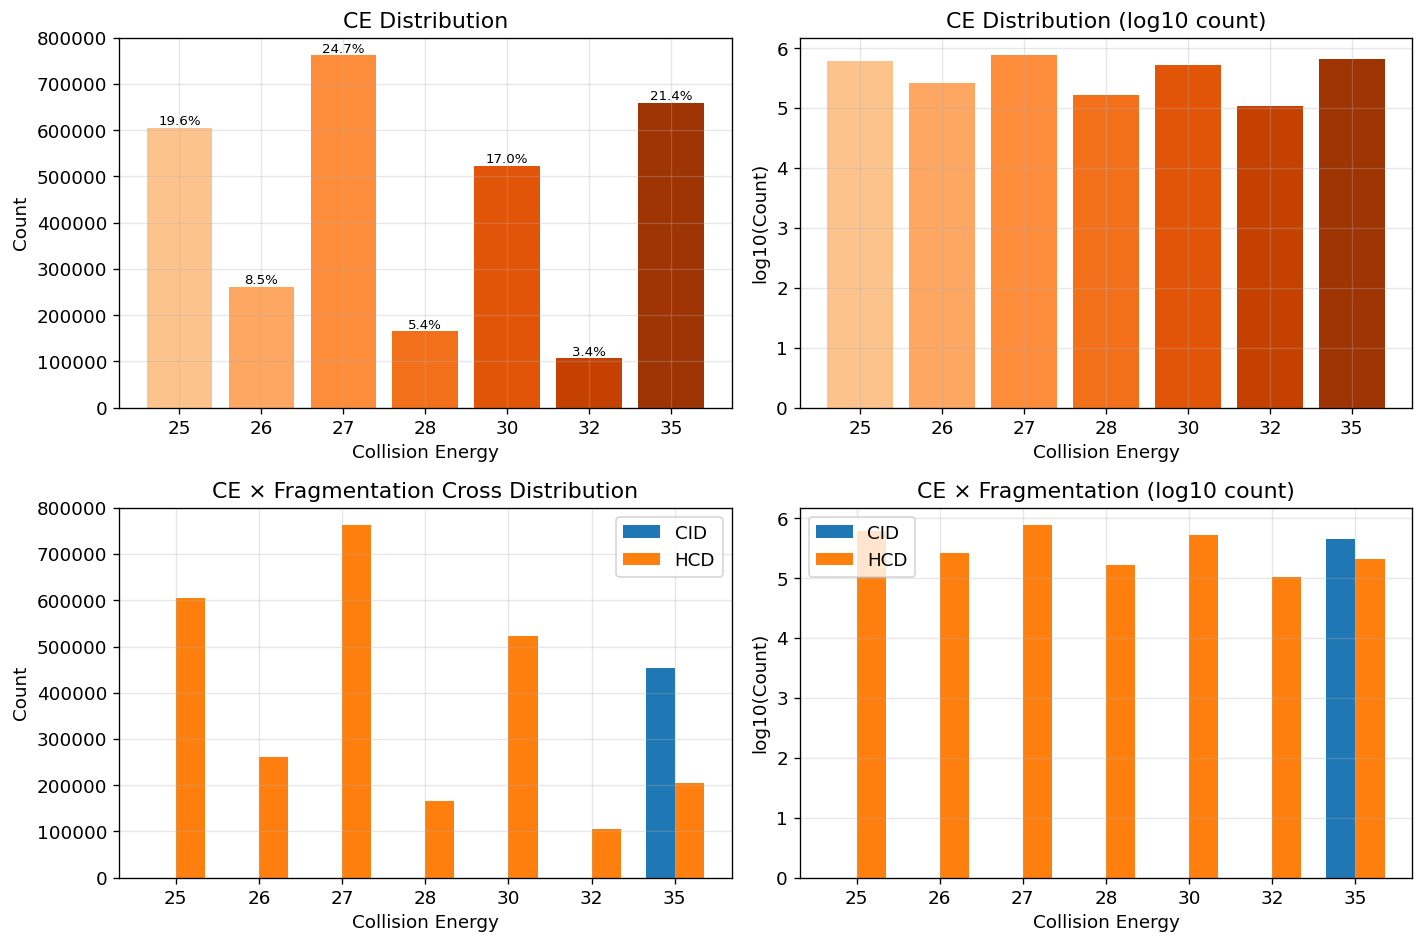

In [33]:
ce_vals, ce_cnts = np.unique(ce, return_counts=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

colors = plt.cm.Oranges(np.linspace(0.3, 0.9, len(ce_vals)))
ce_labels = [f"{v:.0f}" for v in ce_vals]

# 直接对 count 做 log10（0 保持为 0，便于线性 y 轴展示）
log_ce_cnts = np.where(ce_cnts > 0, np.log10(ce_cnts), 0.0)

# CE 分布（线性）
axes[0, 0].bar(ce_labels, ce_cnts, color=colors)
for i, (v, c) in enumerate(zip(ce_vals, ce_cnts)):
    axes[0, 0].text(i, c, f"{c/N*100:.1f}%", ha="center", va="bottom", fontsize=8)
axes[0, 0].set_xlabel("Collision Energy")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("CE Distribution")

# CE 分布（log10(count)）
axes[0, 1].bar(ce_labels, log_ce_cnts, color=colors)
axes[0, 1].set_xlabel("Collision Energy")
axes[0, 1].set_ylabel("log10(Count)")
axes[0, 1].set_title("CE Distribution (log10 count)")

# CE × Fragmentation 交叉分布（线性）
frag_types = np.unique(frag)
bar_width = 0.35
x = np.arange(len(ce_vals))
for i, ft in enumerate(frag_types):
    mask = frag == ft
    ce_sub = ce[mask]
    sub_cnts = np.array([np.sum(ce_sub == v) for v in ce_vals])
    axes[1, 0].bar(x + i * bar_width, sub_cnts, bar_width, label=ft)

axes[1, 0].set_xticks(x + bar_width * (len(frag_types) - 1) / 2)
axes[1, 0].set_xticklabels(ce_labels)
axes[1, 0].set_xlabel("Collision Energy")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("CE × Fragmentation Cross Distribution")
axes[1, 0].legend()

# CE × Fragmentation 交叉分布（log10(count)）
for i, ft in enumerate(frag_types):
    mask = frag == ft
    ce_sub = ce[mask]
    sub_cnts = np.array([np.sum(ce_sub == v) for v in ce_vals])
    log_sub_cnts = np.where(sub_cnts > 0, np.log10(sub_cnts), 0.0)
    axes[1, 1].bar(x + i * bar_width, log_sub_cnts, bar_width, label=ft)

axes[1, 1].set_xticks(x + bar_width * (len(frag_types) - 1) / 2)
axes[1, 1].set_xticklabels(ce_labels)
axes[1, 1].set_xlabel("Collision Energy")
axes[1, 1].set_ylabel("log10(Count)")
axes[1, 1].set_title("CE × Fragmentation (log10 count)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 4. Fragmentation Type Distribution

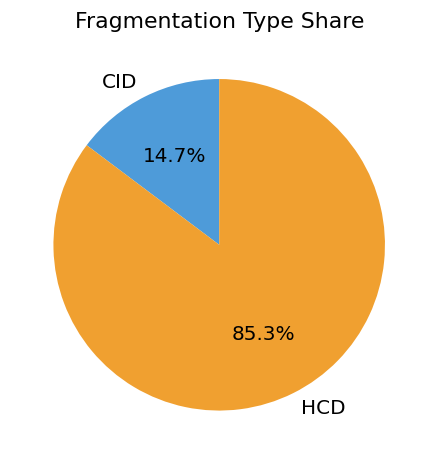

  CID: 454,502 (14.7%)
  HCD: 2,628,417 (85.3%)

HCD:CID ratio = 5.8:1


In [34]:
frag_vals, frag_cnts = np.unique(frag, return_counts=True)

fig, ax = plt.subplots(figsize=(5, 4))
wedges, texts, autotexts = ax.pie(
    frag_cnts,
    labels=frag_vals,
    autopct="%1.1f%%",
    colors=["#4e9bd9", "#f0a030"],
    startangle=90,
    textprops={"fontsize": 12},
)
ax.set_title("Fragmentation Type Share")
plt.tight_layout()
plt.show()

for v, c in zip(frag_vals, frag_cnts):
    print(f"  {v}: {c:,} ({c/N*100:.1f}%)")
print(f"\nHCD:CID ratio = {frag_cnts[frag_vals=='HCD'][0] / frag_cnts[frag_vals=='CID'][0]:.1f}:1")


## 5. Score Distribution

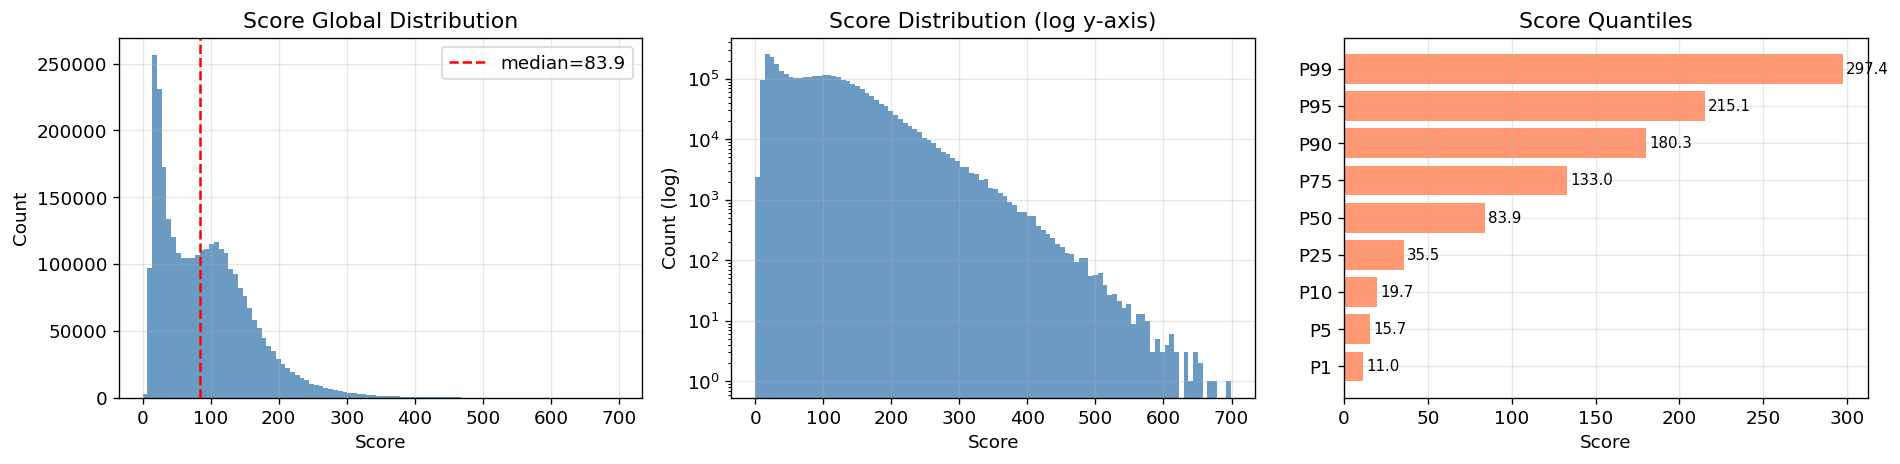

Score stats: mean=93.3, std=66.6, min=0.00, max=699.5
Score < 40 (low quality): 856,847 (27.8%)
Score > 200 (high quality): 207,703 (6.7%)


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 全局直方图
axes[0].hist(score, bins=100, color="steelblue", alpha=0.8, edgecolor="none")
axes[0].axvline(np.median(score), color="red", ls="--", label=f"median={np.median(score):.1f}")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Global Distribution")
axes[0].legend()

# 对数 y 轴
axes[1].hist(score, bins=100, color="steelblue", alpha=0.8, edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Score Distribution (log y-axis)")

# Score Quantiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pvals = np.percentile(score, percentiles)
axes[2].barh([f"P{p}" for p in percentiles], pvals, color="coral", alpha=0.8)
for i, (p, v) in enumerate(zip(percentiles, pvals)):
    axes[2].text(v + 2, i, f"{v:.1f}", va="center", fontsize=9)
axes[2].set_xlabel("Score")
axes[2].set_title("Score Quantiles")

plt.tight_layout()
plt.show()

print(f"Score stats: mean={score.mean():.1f}, std={score.std():.1f}, min={score.min():.2f}, max={score.max():.1f}")
print(f"Score < 40 (low quality): {(score < 40).sum():,} ({(score < 40).sum()/N*100:.1f}%)")
print(f"Score > 200 (high quality): {(score > 200).sum():,} ({(score > 200).sum()/N*100:.1f}%)")

## 6. Modifications Distribution

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (11,) and arg 3 with shape (12,).

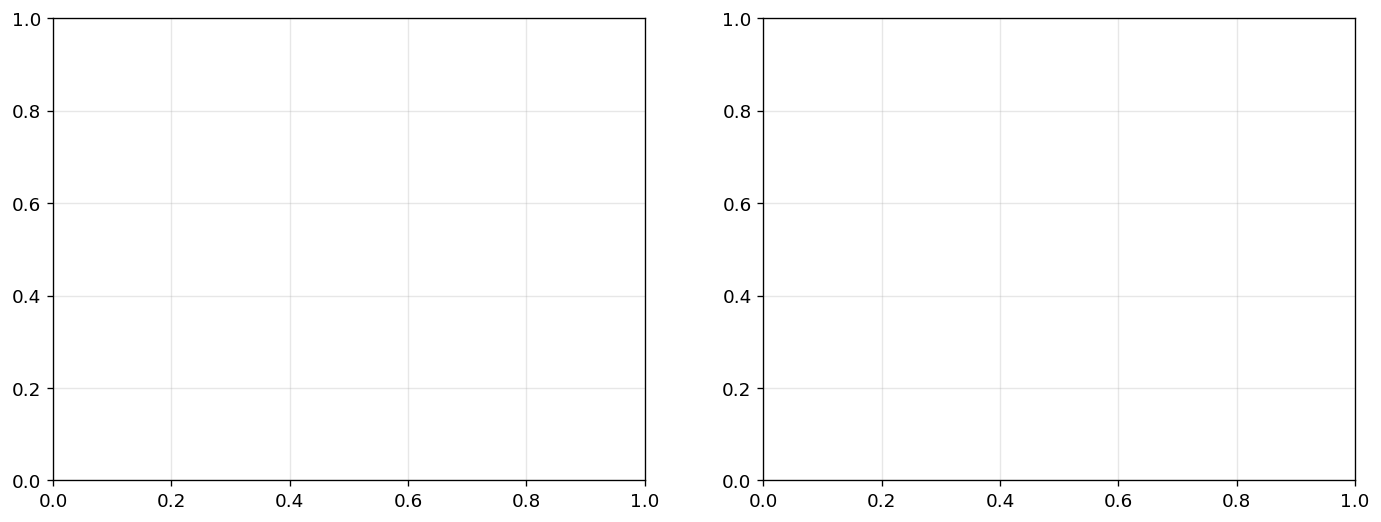

In [36]:
mod_vals, mod_cnts = np.unique(mods, return_counts=True)
order = np.argsort(-mod_cnts)

# 只展示前 12 类
top_k = 12
mod_labels = [mod_vals[i][:30] for i in order[:top_k]]  # 截断长标签
mod_counts = [mod_cnts[i] for i in order[:top_k]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 柱状图
axes[0].barh(range(top_k), mod_counts, color="mediumpurple", alpha=0.8)
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(mod_labels, fontsize=9)
axes[0].invert_yaxis()
for i, c in enumerate(mod_counts):
    axes[0].text(c, i, f" {c:,} ({c/N*100:.1f}%)", va="center", fontsize=8)
axes[0].set_xlabel("Count")
axes[0].set_title(f"Modifications Top {top_k}")

# 简化分类：Unmodified vs 含修饰
has_mod = mods != "Unmodified"
mod_summary = ["Unmodified", "Has Modification"]
mod_summary_cnts = [(~has_mod).sum(), has_mod.sum()]
axes[1].pie(
    mod_summary_cnts,
    labels=mod_summary,
    autopct="%1.1f%%",
    colors=["#90caf9", "#ef9a9a"],
    startangle=90,
    textprops={"fontsize": 12},
)
axes[1].set_title("Modified vs Unmodified")

plt.tight_layout()
plt.show()

print(f"\nTotal mod types: {len(mod_vals)}")
print(f"Unmodified share: {(~has_mod).sum()/N*100:.1f}%")
print(f"Modified share: {has_mod.sum()/N*100:.1f}%")


## 7. Instrument Distribution

/tmp/ipykernel_2923508/3473609040.py:16: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2923508/3473609040.py:16: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/data/home/cliang/miniconda3/envs/mamba_dev/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/home/cliang/miniconda3/envs/mamba_dev/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


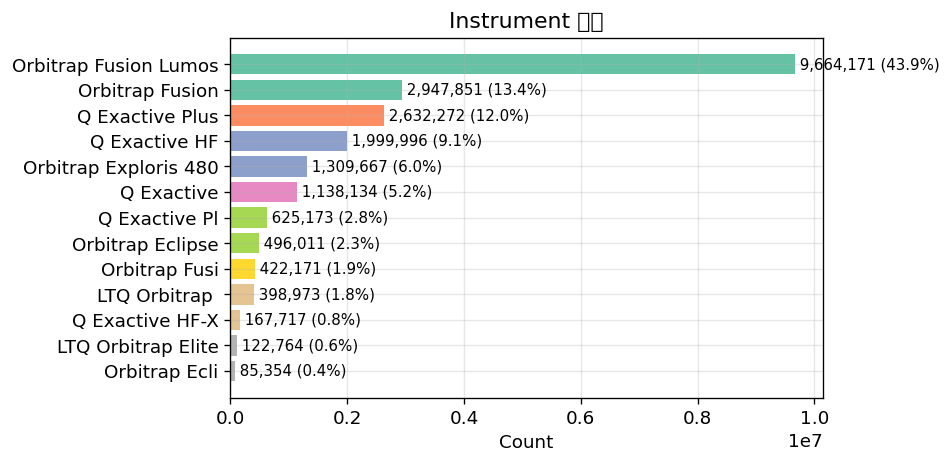

In [ ]:
inst_vals, inst_cnts = np.unique(inst, return_counts=True)
order = np.argsort(-inst_cnts)

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(inst_vals)))
ax.barh(
    [inst_vals[i] for i in order],
    [inst_cnts[i] for i in order],
    color=colors,
)
for i, idx in enumerate(order):
    ax.text(inst_cnts[idx], i, f" {inst_cnts[idx]:,} ({inst_cnts[idx]/N*100:.1f}%)", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title("Instrument Distribution")
plt.tight_layout()
plt.show()

## 8. Dataset Source Distribution (PXD)

/tmp/ipykernel_53363/2698671060.py:33: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2698671060.py:33: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2698671060.py:33: UserWarning: Glyph 25490 (\N{CJK UNIFIED IDEOGRAPH-6392}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2698671060.py:33: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2698671060.py:33: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2698671060.py:33: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2698671060.py:33: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAP

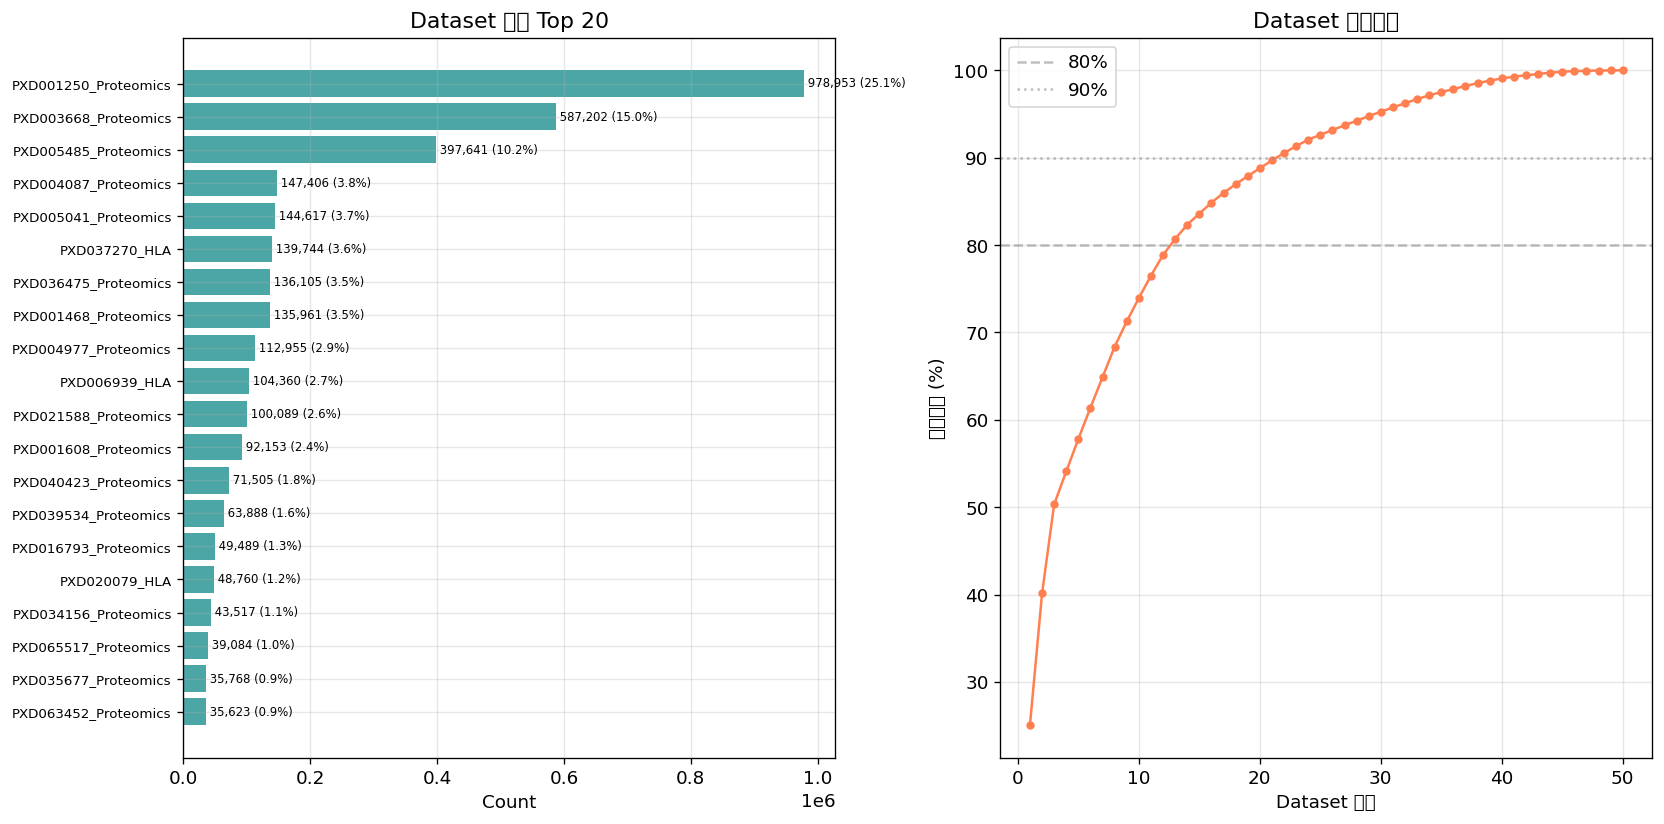

  达到 50% 数据量需要 Top 3 个 dataset
  达到 80% 数据量需要 Top 13 个 dataset
  达到 90% 数据量需要 Top 22 个 dataset
  达到 95% 数据量需要 Top 30 个 dataset
总 dataset 数: 50
Top 3 占比: 50.3%


In [ ]:
ds_vals, ds_cnts = np.unique(dataset, return_counts=True)
order = np.argsort(-ds_cnts)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Top 20
top_k = min(20, len(ds_vals))
axes[0].barh(
    range(top_k),
    [ds_cnts[order[i]] for i in range(top_k)],
    color="teal",
    alpha=0.7,
)
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels([ds_vals[order[i]] for i in range(top_k)], fontsize=8)
axes[0].invert_yaxis()
for i in range(top_k):
    c = ds_cnts[order[i]]
    axes[0].text(c, i, f" {c:,} ({c/N*100:.1f}%)", va="center", fontsize=7)
axes[0].set_xlabel("Count")
axes[0].set_title(f"Dataset Source Top {top_k}")

# 累积占比曲线
cum_pct = np.cumsum(ds_cnts[order]) / N * 100
axes[1].plot(range(1, len(ds_vals) + 1), cum_pct, "o-", ms=4, color="coral")
axes[1].axhline(80, color="gray", ls="--", alpha=0.5, label="80%")
axes[1].axhline(90, color="gray", ls=":", alpha=0.5, label="90%")
axes[1].set_xlabel("Dataset Rank")
axes[1].set_ylabel("Cumulative Share (%)")
axes[1].set_title("Dataset Cumulative Share")
axes[1].legend()

plt.tight_layout()
plt.show()

# 找出 80% 和 90% 占比需要多少个 dataset
for threshold in [50, 80, 90, 95]:
    n_needed = np.searchsorted(cum_pct, threshold) + 1
    print(f"  Top {n_needed} datasets reach {threshold}% of rows")
print(f"\nTotal datasets: {len(ds_vals)}")
print(f"Top-3 share: {cum_pct[2]:.1f}%")


## 9. Cross-tab Heatmap (Charge × Length)

/tmp/ipykernel_53363/1308253262.py:25: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/1308253262.py:25: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/1308253262.py:25: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/1308253262.py:25: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/1308253262.py:25: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/1308253262.py:25: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/1308253262.py:25: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAP

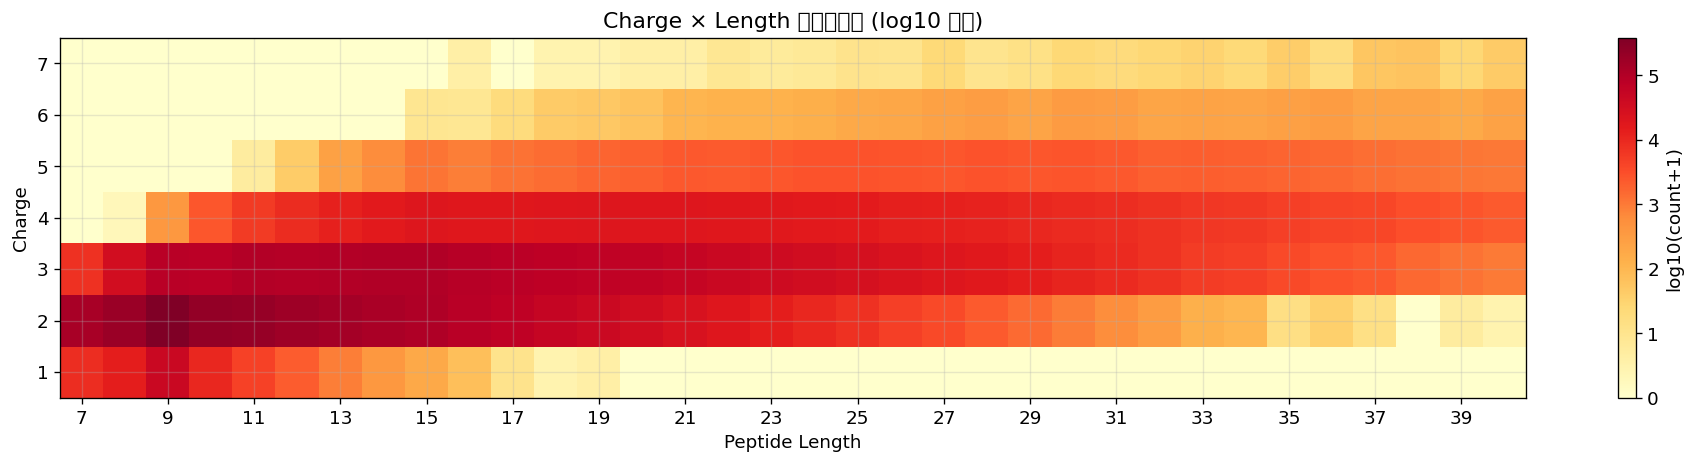

样本数 = 0 的 (Charge, Length) 组合:
  共 45 个空白格子 / 总 238 格 (18.9%)
样本数 < 10 的稀疏组合 (关注 Charge 1, 5-7):
  Charge 1: 总 86,400 行, 稀疏长度格子 23/34
  Charge 5: 总 51,134 行, 稀疏长度格子 5/34
  Charge 6: 总 4,581 行, 稀疏长度格子 10/34
  Charge 7: 总 446 行, 稀疏长度格子 20/34


In [ ]:
charge_range = np.arange(1, 8)
length_range = np.arange(7, 41)
heatmap = np.zeros((len(charge_range), len(length_range)), dtype=np.int64)

for ci, ch in enumerate(charge_range):
    mask_ch = charge == ch
    for li, ln in enumerate(length_range):
        heatmap[ci, li] = np.sum(mask_ch & (length == ln))

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(
    np.log10(heatmap + 1),
    aspect="auto",
    cmap="YlOrRd",
    origin="lower",
)
ax.set_xticks(np.arange(0, len(length_range), 2))
ax.set_xticklabels(length_range[::2])
ax.set_yticks(range(len(charge_range)))
ax.set_yticklabels(charge_range)
ax.set_xlabel("Peptide Length")
ax.set_ylabel("Charge")
ax.set_title("Charge × Length Heatmap (log10 count)")
plt.colorbar(im, ax=ax, label="log10(count+1)")
plt.tight_layout()
plt.show()

# 找出空白区域
print("\nZero-count (Charge, Length) bins:")
empty_count = 0
for ci, ch in enumerate(charge_range):
    for li, ln in enumerate(length_range):
        if heatmap[ci, li] == 0:
            empty_count += 1
print(f"  {empty_count} empty cells / {heatmap.size} total ({empty_count/heatmap.size*100:.1f}%)")

print("\nSparse bins (count < 10; Charge 1, 5-7):")
for ci, ch in enumerate(charge_range):
    if ch in [1, 5, 6, 7]:
        total_ch = heatmap[ci].sum()
        sparse = (heatmap[ci] < 10).sum()
        print(f"  Charge {ch}: {total_ch:,} rows, sparse length bins {sparse}/{len(length_range)}")


## 10. Cross-tab Heatmap (Charge × CE)

/tmp/ipykernel_53363/358729863.py:33: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/358729863.py:33: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/358729863.py:33: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/358729863.py:33: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/358729863.py:33: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/358729863.py:33: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/358729863.py:33: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}

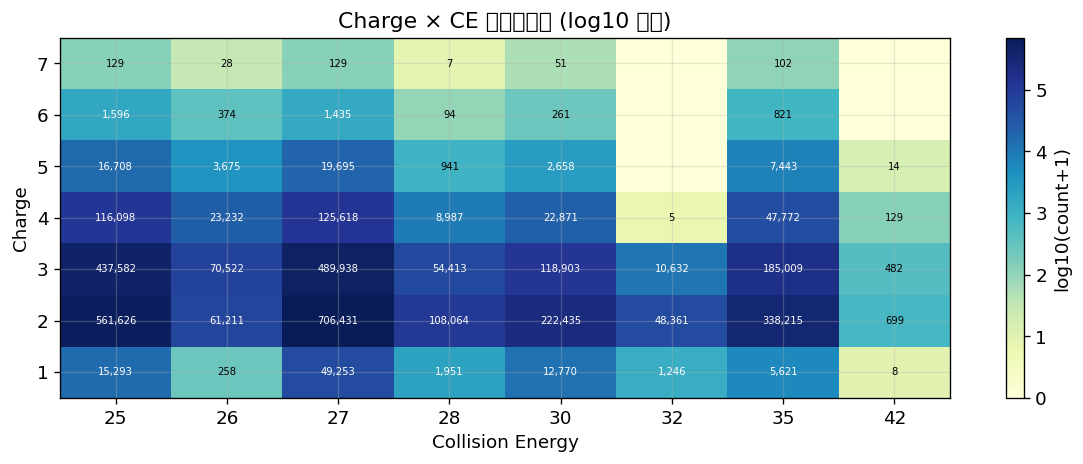

In [ ]:
ce_unique = np.sort(np.unique(ce))
heatmap_ce = np.zeros((len(charge_range), len(ce_unique)), dtype=np.int64)

for ci, ch in enumerate(charge_range):
    mask_ch = charge == ch
    for ei, ev in enumerate(ce_unique):
        heatmap_ce[ci, ei] = np.sum(mask_ch & (ce == ev))

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    np.log10(heatmap_ce + 1),
    aspect="auto",
    cmap="YlGnBu",
    origin="lower",
)
ax.set_xticks(range(len(ce_unique)))
ax.set_xticklabels([f"{v:.0f}" for v in ce_unique])
ax.set_yticks(range(len(charge_range)))
ax.set_yticklabels(charge_range)
ax.set_xlabel("Collision Energy")
ax.set_ylabel("Charge")
ax.set_title("Charge × CE Heatmap (log10 count)")

# 在格子内标注实际数量
for ci in range(len(charge_range)):
    for ei in range(len(ce_unique)):
        val = heatmap_ce[ci, ei]
        if val > 0:
            ax.text(ei, ci, f"{val:,}", ha="center", va="center", fontsize=6,
                    color="white" if np.log10(val + 1) > 3 else "black")

plt.colorbar(im, ax=ax, label="log10(count+1)")
plt.tight_layout()
plt.show()

## 11. train_data Matrix Features (Sampled)

train_data shape: (3901796, 39, 41)
抽样 5000 条, 每条 shape = (39, 41)


/tmp/ipykernel_53363/2530228229.py:36: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:36: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:36: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:36: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:36: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:36: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAP

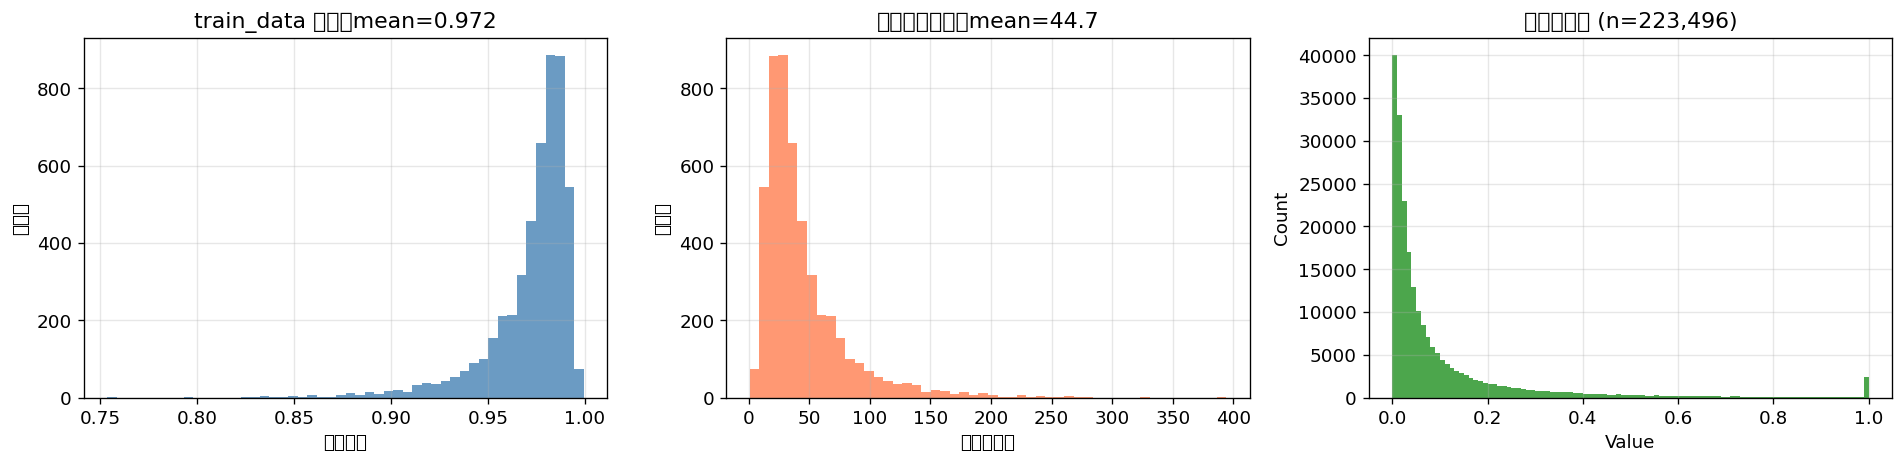

/tmp/ipykernel_53363/2530228229.py:47: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:47: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:47: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:47: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:47: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:47: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/2530228229.py:47: UserWarning: Glyph 25277 (\N{CJK UNIFIED IDEOGRAP

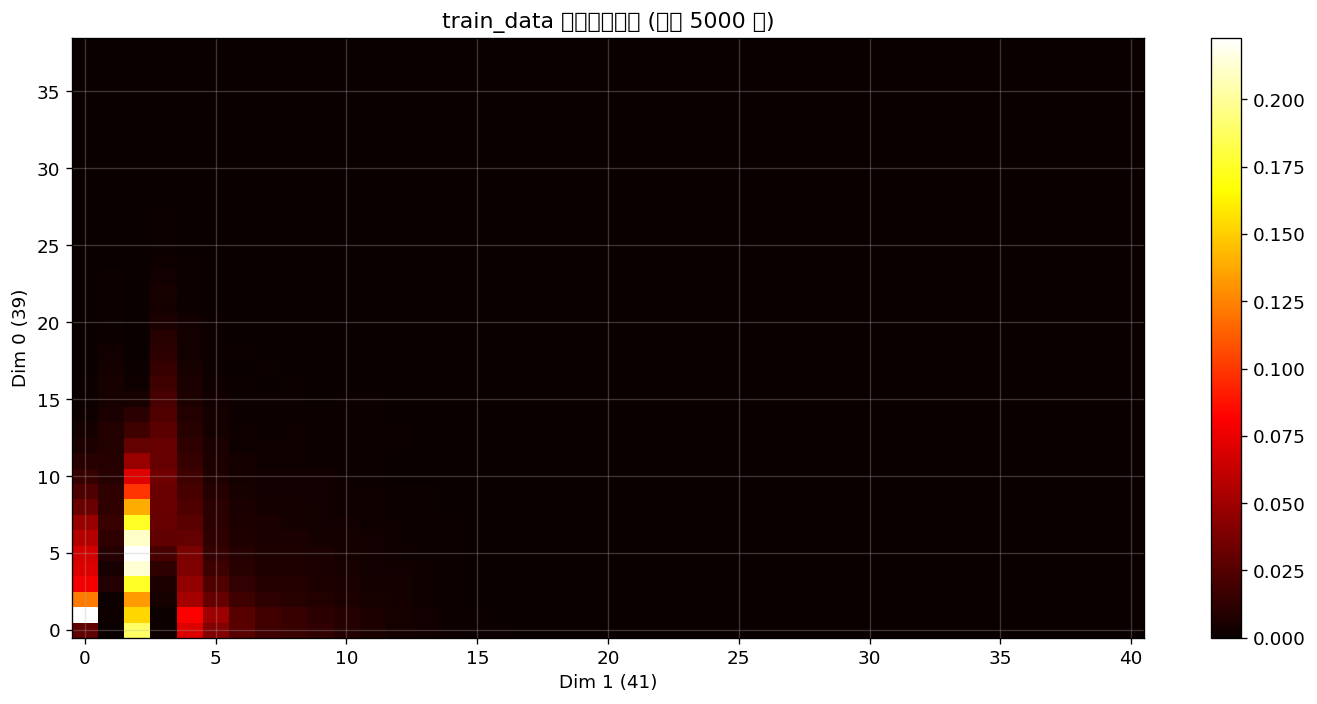

In [ ]:
# 随机抽取 5000 条分析 train_data 的稀疏度和数值分布
np.random.seed(42)
sample_idx = np.sort(np.random.choice(N, size=min(5000, N), replace=False))
td_sample = f["train_data"][sample_idx.tolist()]

print(f"train_data shape: {f['train_data'].shape}")
print(f"Sampled {td_sample.shape[0]} rows, shape = {td_sample.shape[1:]}")

# 稀疏度：Zero Fraction
zero_ratio_per_sample = (td_sample == 0).sum(axis=(1, 2)) / (39 * 41)
nonzero_per_sample = (td_sample != 0).sum(axis=(1, 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Zero Fraction分布
axes[0].hist(zero_ratio_per_sample, bins=50, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Zero Fraction")
axes[0].set_ylabel("Sample Count")
axes[0].set_title(f"train_data Sparsity\nmean={zero_ratio_per_sample.mean():.3f}")

# 非零值数量分布
axes[1].hist(nonzero_per_sample, bins=50, color="coral", alpha=0.8)
axes[1].set_xlabel("Non-zero Count")
axes[1].set_ylabel("Sample Count")
axes[1].set_title(f"Non-zero Count Distribution\nmean={nonzero_per_sample.mean():.1f}")

# 非零值的数值分布
nonzero_vals = td_sample[td_sample != 0]
axes[2].hist(nonzero_vals, bins=100, color="green", alpha=0.7)
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Count")
axes[2].set_title(f"Non-zero Value Distribution (n={nonzero_vals.size:,})")

plt.tight_layout()
plt.show()

# 平均 train_data 热力图
mean_td = td_sample.mean(axis=0)
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(mean_td, aspect="auto", cmap="hot", origin="lower")
ax.set_xlabel("Dim 1 (41)")
ax.set_ylabel("Dim 0 (39)")
ax.set_title("train_data Mean Heatmap (n=5000 sample)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 12. Unique Peptide Sequence Statistics

唯一 Sequence 数: 822,878
总记录数: 3,901,796
平均每序列出现次数: 4.74


/tmp/ipykernel_53363/4143839858.py:28: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/4143839858.py:28: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/4143839858.py:28: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/4143839858.py:28: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/4143839858.py:28: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/4143839858.py:28: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53363/4143839858.py:28: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAP

/data/home/cliang/miniconda3/envs/mamba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/home/cliang/miniconda3/envs/mamba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/home/cliang/miniconda3/envs/mamba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/home/cliang/miniconda3/envs/mamba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/home/cliang/miniconda3/envs/mamba/lib/python3.12/site-

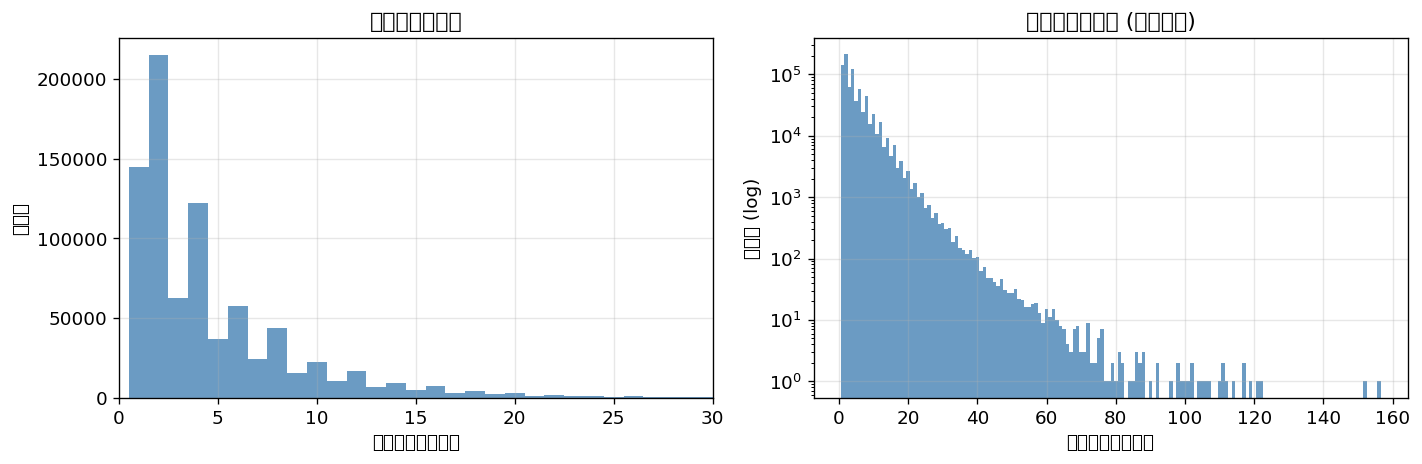

只出现 1 次的序列: 144,661 (17.6%)
出现 2 次的序列: 215,143
出现 > 10 次的序列: 77,273
出现最多的序列: 156 次


In [ ]:
# 唯一Sequence Count
uniq_seq = np.unique(sequence)
print(f"Unique sequences: {len(uniq_seq):,}")
print(f"Total records: {N:,}")
print(f"Mean occurrences per sequence: {N / len(uniq_seq):.2f}")

# 每个序列出现的次数分布
from collections import Counter
seq_counter = Counter(sequence.tolist())
repeat_counts = np.array(list(seq_counter.values()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(repeat_counts, bins=np.arange(1, repeat_counts.max() + 2) - 0.5,
             color="steelblue", alpha=0.8, edgecolor="none")
axes[0].set_xlabel("Occurrences per Sequence")
axes[0].set_ylabel("Sequence Count")
axes[0].set_title("Sequence Repeat Distribution")
axes[0].set_xlim(0, 30)

axes[1].hist(repeat_counts, bins=np.arange(1, repeat_counts.max() + 2) - 0.5,
             color="steelblue", alpha=0.8, edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_xlabel("Occurrences per Sequence")
axes[1].set_ylabel("Sequence Count (log)")
axes[1].set_title("Sequence Repeat Distribution (log y-axis)")

plt.tight_layout()
plt.show()

print(f"\nSingleton sequences: {(repeat_counts == 1).sum():,} ({(repeat_counts == 1).sum()/len(uniq_seq)*100:.1f}%)")
print(f"Dup-2 sequences: {(repeat_counts == 2).sum():,}")
print(f"Sequences with >10 occurrences: {(repeat_counts > 10).sum():,}")
print(f"Max occurrences per sequence: {repeat_counts.max()}")


---

## 13. Imbalance Summary & Training Balance Notes

In [ ]:
# ========== 不平衡量化 ==========
print("=" * 70)
print("                    Imbalance Report")
print("=" * 70)

def imbalance_ratio(vals, cnts):
    """最大类 / 最小类 的比值"""
    return cnts.max() / cnts.min()

def entropy_ratio(cnts):
    """实际熵 / 最大熵，1.0 = 完美均匀"""
    p = cnts / cnts.sum()
    h = -np.sum(p * np.log2(p + 1e-12))
    h_max = np.log2(len(cnts))
    return h / h_max if h_max > 0 else 1.0

features = {
    "Charge": (np.unique(charge, return_counts=True)),
    "Fragmentation": (np.unique(frag, return_counts=True)),
    "Collision Energy": (np.unique(ce, return_counts=True)),
    "Instrument": (np.unique(inst, return_counts=True)),
    "Modifications": (np.array(["Unmod", "Modified"]),
                      np.array([(mods == "Unmodified").sum(), (mods != "Unmodified").sum()])),
}

print(f"{'Feature':<20} {'#classes':>6} {'max/min':>10} {'entropy':>10} {'level':>12}")
print("-" * 70)
for name, (vals, cnts) in features.items():
    ir = imbalance_ratio(vals, cnts)
    er = entropy_ratio(cnts)
    if er > 0.9:
        level = "OK"
    elif er > 0.7:
        level = "moderate"
    else:
        level = "severe"
    print(f"{name:<20} {len(vals):>6} {ir:>10.0f}x {er:>10.3f} {level:>12}")

print("\
" + "=" * 70)

                    数据不平衡量化报告


特征                      类别数      最大/最小       熵均匀度        不平衡等级
----------------------------------------------------------------------
Charge                    7       4590x      0.550      🔴 严重不平衡
Fragmentation             2          8x      0.522      🔴 严重不平衡
Collision Energy          8       1045x      0.758     ⚠️ 中度不平衡
Instrument                6         14x      0.879     ⚠️ 中度不平衡
Modifications             2         10x      0.448      🔴 严重不平衡


## 14. Data Balancing Strategy Notes

基于上面的分布分析，以下是深度学习训练时的数据平衡建议：

### Issue 1: Severe Charge Imbalance (z2+z3 87.5%; z6+z7 0.1%)

| 策略 | 具体做法 | 适用场景 |
|------|---------|----------|
| **采样权重 (推荐)** | 训练时给每个样本赋予 `weight = 1 / count(charge)`，让稀有 charge 的梯度贡献放大 | DataLoader 的 `WeightedRandomSampler` |
| **分层采样** | 每个 epoch 按 charge 分层，每层采等量样本（如每层 5 万），小类过采样 | 最简单直接 |
| **丢弃极少数类** | Charge 6、7 合计 5027 条（0.13%），样本量太少难以学好，考虑丢弃或合并到 z≥5 | 减少噪声 |
| **补充数据** | 从 ITMS 或新的 PXD 来源引入更多 z1、z4、z5 数据 | 长期方案 |

### Issue 2: Fragmentation Imbalance (HCD 88% vs CID 12%)

| 策略 | 具体做法 |
|------|----------|
| **分 fragmentation 训练** | HCD 和 CID 分别训练模型，或用 fragmentation 类型作为 conditioning 输入 |
| **过采样 CID** | 对 CID 样本做 ~7.5x 过采样，或在 loss 中给 CID 更高权重 |
| **引入 ETD/EThcD** | 当前数据只有 HCD+CID，若模型需要泛化到其他碎裂方式，需补充 ETD 等数据 |

### Issue 3: Collision Energy Peaked at 25-27

| 策略 | 具体做法 |
|------|----------|
| **CE 归一化** | 将 CE 作为连续输入特征（而非类别），避免离散化导致未见 CE 泛化差 |
| **补充 CE 30-40 数据** | CE=32 仅 1.5%，CE=42 仅 1332 条；从新来源补充中高 CE 范围数据 |
| **CE 作为 conditioning** | 让模型学到 CE 对碎裂模式的连续影响，而非死记离散 CE 值 |

### Issue 4: Modifications Skewed (90.6% Unmodified)

| 策略 | 具体做法 |
|------|----------|
| **两阶段训练** | 先在全量数据训练基础模型，再在修饰子集上 fine-tune |
| **修饰类型 embedding** | 将修饰类型编码为额外特征输入，让模型显式感知修饰差异 |
| **过采样 + 增强** | 含修饰的样本做 5-10x 过采样；或用序列扰动生成增强数据 |

### Issue 5: Dataset Source Bias (Top 3 = 50%)

| 策略 | 具体做法 |
|------|----------|
| **来源平衡采样** | 按 dataset/PXD 来源分层，每个 epoch 每个来源采等量数据（如 10k-50k） |
| **来源作 batch 特征** | 若不同仪器/实验室的谱图有系统偏差，考虑 batch normalization 或 domain adaptation |

### Recommended Combined Strategy

针对 MS2 强度预测的训练场景，推荐以下组合策略：

In [ ]:
# ========== 综合平衡方案：生成采样权重示例 ==========
# 组合考虑 Charge + Fragmentation + CE 三个关键维度

from itertools import product

print("Combined sampling weights: (Charge, Fragmentation, CE) groups")
print("Weight ∝ 1/group size for balanced sampling\n")

# 构建联合分组 key
group_keys = list(zip(charge.tolist(), frag.tolist(), ce.tolist()))
group_counter = Counter(group_keys)

print(f"# groups: {len(group_counter)}")
print(f"Largest group: {max(group_counter.values()):,} rows")
print(f"Smallest group: {min(group_counter.values()):,} rows")
print(f"Max/min ratio: {max(group_counter.values()) / min(group_counter.values()):.0f}x")

# 展示前 20 组
print("\nTop 20 groups (by size):")
for (ch, fr, c), cnt in sorted(group_counter.items(), key=lambda x: -x[1])[:20]:
    print(f"  z={ch}, {fr}, CE={c:.0f}: {cnt:,} ({cnt/N*100:.2f}%)")

print("\nBottom 10 groups (rarest):")
for (ch, fr, c), cnt in sorted(group_counter.items(), key=lambda x: x[1])[:10]:
    print(f"  z={ch}, {fr}, CE={c:.0f}: {cnt:,}")


综合采样权重方案: 按 (Charge, Fragmentation, CE) 联合分组
每组获得与组大小成反比的权重，实现组间平衡采样


联合分组数: 63
最大组: 706,431 条
最小组: 4 条
最大/最小比: 176608x
Top 20 组 (按大小):
  z=2, HCD, CE=27: 706,431 (18.11%)
  z=2, HCD, CE=25: 561,626 (14.39%)
  z=3, HCD, CE=27: 489,938 (12.56%)
  z=3, HCD, CE=25: 437,582 (11.21%)
  z=2, CID, CE=35: 268,092 (6.87%)
  z=2, HCD, CE=30: 218,773 (5.61%)
  z=3, CID, CE=35: 136,677 (3.50%)
  z=4, HCD, CE=27: 125,618 (3.22%)
  z=4, HCD, CE=25: 116,098 (2.98%)
  z=3, HCD, CE=30: 114,792 (2.94%)
  z=2, HCD, CE=28: 108,064 (2.77%)
  z=3, HCD, CE=26: 70,522 (1.81%)
  z=2, HCD, CE=35: 70,123 (1.80%)
  z=2, HCD, CE=26: 61,211 (1.57%)
  z=3, HCD, CE=28: 54,413 (1.39%)
  z=1, HCD, CE=27: 49,253 (1.26%)
  z=2, HCD, CE=32: 48,361 (1.24%)
  z=3, HCD, CE=35: 48,332 (1.24%)
  z=4, CID, CE=35: 34,901 (0.89%)
  z=4, HCD, CE=26: 23,232 (0.60%)
Bottom 10 组 (最稀缺):
  z=1, CID, CE=30: 4
  z=5, CID, CE=30: 4
  z=4, HCD, CE=32: 5
  z=7, HCD, CE=28: 7
  z=1, HCD, CE=42: 8
  z=5, HCD, CE=42: 14
  z=7, HCD, CE=26: 28
  z=7, HCD, CE=35: 33
  z=7, HCD, CE=30: 51
  z=7, CID, CE=35: 69


In [ ]:
# ========== 样本权重计算示例代码 ==========
# 可直接复用到训练 DataLoader

def compute_sample_weights(charge, frag, ce, smooth_power=0.5):
    """
    计算每条样本的采样权重。
    
    smooth_power 控制平衡强度:
        1.0 = 完全平衡（每组等概率采样）
        0.5 = 开方平滑（推荐，兼顾平衡与大组优势）
        0.0 = 不平衡（原始分布）
    """
    # 构建联合分组
    keys = list(zip(charge.tolist(), frag.tolist(), ce.tolist()))
    counter = Counter(keys)
    
    # 权重 = 1 / count^smooth_power
    weights = np.array([1.0 / (counter[k] ** smooth_power) for k in keys])
    weights /= weights.sum()  # 归一化
    return weights

# 示例
w = compute_sample_weights(charge, frag, ce, smooth_power=0.5)
print("Sampling weight stats (smooth_power=0.5):")
print(f"  min weight: {w.min():.2e}")
print(f"  max weight: {w.max():.2e}")
print(f"  max/min ratio: {w.max()/w.min():.0f}x")
print(f"  effective sample size: {1.0 / (w**2).sum():,.0f} (raw {N:,})")

print("\nUsage:")
print("  from torch.utils.data import WeightedRandomSampler")
print("  sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)")
print("  loader = DataLoader(dataset, sampler=sampler, batch_size=256)")


采样权重统计 (smooth_power=0.5):
  min weight: 1.25e-07
  max weight: 5.23e-05
  max/min ratio: 420x
  effective sample size: 1,448,809 (原始 3,901,796)
使用方式:
  from torch.utils.data import WeightedRandomSampler
  sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
  loader = DataLoader(dataset, sampler=sampler, batch_size=256)


### Data Gap Priority List

根据现有数据缺口，按优先级排列需要补充的数据：

| 优先级 | 缺口 | 当前状况 | 建议补充量 | 数据来源建议 |
|--------|------|----------|-----------|-------------|
| P0 | **CID 碎裂数据** | 仅 45.8 万条 (11.7%) | +100 万条 | 寻找 CID 为主的 PXD 数据集 |
| P0 | **CE 30-40 范围** | CE=30 仅 9.7%, CE=32 仅 1.5% | +50 万条 | 来自不同 NCE 设置的实验 |
| P1 | **Charge 1+ 数据** | 仅 8.6 万条 (2.2%) | +20 万条 | 小分子肽/HLA 肽数据集 |
| P1 | **Charge 4+ 数据** | 仅 34.5 万条 (8.8%) | +20 万条 | 长肽/交联肽数据集 |
| P2 | **含修饰肽段** | 仅 9.4% 含修饰 | +30 万条 | 磷酸化/乙酰化专项数据集 |
| P2 | **长肽 (>25aa)** | 仅 ~2% | +10 万条 | HLA-II / top-down 数据 |
| P3 | **更多仪器类型** | 仅 6 种 | +20 万条 | timsTOF / Astral 等新仪器 |

In [ ]:
# 关闭文件
f.close()
print("H5 file closed")

H5 文件已关闭
